In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.


umagaba_metropt_path = kagglehub.dataset_download('umagaba/metropt')

print('Data source import complete.')


100%|██████████| 154M/154M [00:01<00:00, 91.2MB/s]

Extracting files...


Data source import complete.


In [ ]:
!pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm, trange
import time
from tensorflow.keras.callbacks import TensorBoard, ProgbarLogger

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 608.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.4 MB/s eta 0:00:00


In [ ]:
# Data Loading and Preprocessing
def load_and_preprocess_data():
    """
    Load and preprocess the dataset

    Returns:
        tuple: X_train_scaled, X_test_scaled, y_train_fault, y_test_fault, y_train_fault_type, y_test_fault_type,
               features, fault_type_mapping
    """
    print("Loading and preprocessing data...")
    # Load the dataset
    df = pd.read_csv(umagaba_metropt_path +'/MetroPT1.csv', parse_dates=['timestamp'])
    df.sort_values('timestamp', inplace=True)

    # Basic data exploration
    print("Dataset Information:")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Handle missing values
    print("Handling missing values...")
    df.fillna(df.mean(), inplace=True)

    # Feature selection and engineering
    print("Performing feature engineering...")
    failure_periods = {
        'Air leak on clients': ('2022-02-28 21:53:00', '2022-03-1 02:00:00'),
        'Air leak on air dryer': ('2022-03-23 14:54:00', '2022-03-23 15:24:00'),
        'Oil leak on compressor': ('2022-05-30 12:00:00', '2022-06-02 12:00:00')
    }

    # Create numerical labels
    fault_type_mapping = {
        0: 'No Fault',
        1: 'Air leak on clients',
        2: 'Air leak on air dryer',
        3: 'Oil leak on compressor'
    }

    df['fault'] = 0
    df['fault_type'] = 0

    for idx, (fault_name, (start, end)) in enumerate(tqdm(failure_periods.items(), desc="Labeling fault periods"), 1):
        mask = (df['timestamp'] >= pd.to_datetime(start)) & (df['timestamp'] <= pd.to_datetime(end))
        df.loc[mask, 'fault'] = 1
        df.loc[mask, 'fault_type'] = idx

    # Feature selection
    features = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
                'Oil_temperature', 'Motor_current', 'COMP']
    target_fault = 'fault'
    target_fault_type = 'fault_type'

    print("Splitting data into train and test sets...")
    # Extract features and targets
    X = df[features]
    y_fault = df[target_fault]
    y_fault_type = df[target_fault_type]

    # Perform random train-test split
    X_train, X_test, y_train_fault, y_test_fault, y_train_fault_type, y_test_fault_type = train_test_split(
        X, y_fault, y_fault_type, test_size=0.2, random_state=42, stratify=y_fault_type
    )

    # Scaling features
    print("Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Data preprocessing completed!")
    #visualize_data(df)
    return (X_train, X_test, X_train_scaled, X_test_scaled,
            y_train_fault, y_test_fault,
            y_train_fault_type, y_test_fault_type,
            features, fault_type_mapping)
(X_train, X_test, X_train_scaled, X_test_scaled,
y_train_fault, y_test_fault,
y_train_fault_type, y_test_fault_type,
features, fault_type_mapping) = load_and_preprocess_data()

Loading and preprocessing data...
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10773588 entries, 0 to 10773587
Data columns (total 21 columns):
 #   Column           Dtype         
---  ------           -----         
 0   timestamp        datetime64[ns]
 1   TP2              float64       
 2   TP3              float64       
 3   H1               float64       
 4   DV_pressure      float64       
 5   Reservoirs       float64       
 6   Oil_temperature  float64       
 7   Flowmeter        float64       
 8   Motor_current    float64       
 9   COMP             int64         
 10  DV_eletric       int64         
 11  Towers           int64         
 12  MPG              int64         
 13  LPS              int64         
 14  Pressure_switch  int64         
 15  Oil_level        int64         
 16  Caudal_impulses  int64         
 17  gpsLong          float64       
 18  gpsLat           float64       
 19  gpsSpeed         int64         
 20  gpsQuality 

Labeling fault periods: 100%|██████████| 3/3 [00:00<00:00, 12.35it/s]


Splitting data into train and test sets...
Scaling features...
Data preprocessing completed!


In [ ]:
!pip install xgboost
import xgboost as xgb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 MB 3.4 MB/s eta 0:00:00


In [ ]:
# Improved XGBoost for Remaining Useful Life (RUL) Estimation


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def extract_statistical_features(window):
    """
    Extract statistical features from a time window.

    Args:
        window (array): Time window of features.

    Returns:
        array: Statistical features extracted from window.
    """
    # Calculate statistical features for each sensor/feature column
    features = []

    # For each feature/sensor in the window
    for i in range(window.shape[1]):
        sensor_data = window[:, i]

        # Basic statistics
        features.append(np.mean(sensor_data))
        features.append(np.std(sensor_data))
        features.append(np.min(sensor_data))
        features.append(np.max(sensor_data))

        # Trend features
        if len(sensor_data) > 1:
            # Linear trend (simple slope calculation)
            features.append((sensor_data[-1] - sensor_data[0]) / len(sensor_data))

            # Rate of change
            features.append(np.mean(np.diff(sensor_data)))

        # Frequency domain features (if window is large enough)
        if len(sensor_data) > 10:
            # Using FFT for frequency analysis
            fft_vals = np.abs(np.fft.fft(sensor_data))
            features.append(np.mean(fft_vals[1:len(fft_vals)//2]))  # Mean of frequency components
            features.append(np.max(fft_vals[1:len(fft_vals)//2]))   # Dominant frequency magnitude

    return np.array(features)

def prepare_xgboost_data(df, features, target='fault', window_size=10, step_size=1):
    """
    Prepare data for XGBoost RUL estimation with statistical features from time windows.

    Args:
        df (DataFrame): DataFrame containing features and target.
        features (list): List of feature column names.
        target (str): Name of the target column.
        window_size (int): Size of the time window.
        step_size (int): Step size for sliding window.

    Returns:
        tuple: Arrays for XGBoost input and output, and the scaler object.
    """
    print("Preparing XGBoost data with statistical features...")
    X = df[features].values
    y = df[target].values

    # For XGBoost, we'll extract statistical features from the sequences
    X_xgb = []
    y_xgb = []

    print(f"Creating sequences with window size {window_size}...")
    for i in tqdm(range(0, len(X) - window_size, step_size), desc="Creating Feature Windows"):
        # Extract statistical features from the window
        window_features = extract_statistical_features(X[i:i + window_size])
        X_xgb.append(window_features)
        y_xgb.append(y[i + window_size - 1])  # Use the last value in the window

    X_xgb = np.array(X_xgb)
    y_xgb = np.array(y_xgb)

    # Only now apply scaling to the extracted features
    scaler = StandardScaler()  # StandardScaler often works better than MinMaxScaler for XGBoost
    X_xgb_scaled = scaler.fit_transform(X_xgb)

    return X_xgb_scaled, y_xgb, scaler

def optimize_xgboost_model(X_train, y_train, X_val, y_val):
    """
    Optimize XGBoost model using grid search.

    Args:
        X_train, y_train: Training data
        X_val, y_val: Validation data

    Returns:
        model: Optimized XGBoost model.
    """
    print("Optimizing XGBoost hyperparameters...")

    # Parameter grid for GridSearchCV
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'min_child_weight': [1, 3]
    }

    # Base XGBoost model
    base_model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    # Grid search
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    # Fit grid search
    grid_search.fit(X_train, y_train)

    # Get best parameters
    best_params = grid_search.best_params_
    print(f"Best parameters: {best_params}")

    # Create model with best parameters
    model = XGBRegressor(
        n_estimators=best_params['n_estimators'],
        learning_rate=best_params['learning_rate'],
        max_depth=best_params['max_depth'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        min_child_weight=best_params['min_child_weight'],
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    # Train model with early stopping
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=2
    )

    return model

def train_xgboost_model(X_xgb, y_xgb):
    """
    Train the XGBoost model with optimization.

    Args:
        X_xgb (array): Input features for XGBoost.
        y_xgb (array): Target values.

    Returns:
        model: Trained XGBoost model.
    """
    print(f"XGBoost input shape: {X_xgb.shape}")

    # Split data into train, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_xgb, y_xgb, test_size=0.3, random_state=42)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42)

    print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

    # Optimize and train model
    model = optimize_xgboost_model(X_train, y_train, X_val, y_val)

    # Evaluate on test set
    y_pred = model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\nFinal XGBoost Evaluation on Test Set:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Plot training history
    results = model.evals_result()
    epochs = len(results['validation_0']['rmse'])

    plt.figure(figsize=(10, 5))
    plt.plot(range(epochs), results['validation_0']['rmse'], label='Training RMSE')
    plt.plot(range(epochs), results['validation_1']['rmse'], label='Validation RMSE')
    plt.title('XGBoost Model Training History')
    plt.xlabel('Epochs')
    plt.ylabel('RMSE')
    plt.legend()
    plt.tight_layout()
    plt.grid(True)

    # Feature importance
    plt.figure(figsize=(12, 6))
    feature_importance = model.feature_importances_
    # Create descriptive feature names
    feature_names = [f'feature_{i}' for i in range(len(feature_importance))]
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(20)
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.title('XGBoost Feature Importance')
    plt.xlabel('Importance')
    plt.tight_layout()

    return model, X_test, y_test, y_pred

def xgboost_rul_estimation(X_train, X_test, y_train_fault, y_test_fault, features):
    """
    Perform RUL estimation using XGBoost with improved methodology.

    Args:
        X_train, X_test: Training and test dataframes
        y_train_fault, y_test_fault: Fault labels
        features: List of feature names

    Returns:
        tuple: (xgb_model, predictions, actual_values)
    """
    # Combine datasets for consistent processing
    X_combined = pd.concat([X_train, X_test]).reset_index(drop=True)
    y_combined = pd.concat([y_train_fault, y_test_fault]).reset_index(drop=True)

    # Create a dataframe with both features and target
    combined_df = X_combined.copy()
    combined_df['fault'] = y_combined.values

    # Create sequence data for XGBoost with statistical features
    window_size = 30  # Adjusted window size
    step_size = 10     # Add step size for more efficient training

    X_xgb, y_xgb, scaler = prepare_xgboost_data(
        combined_df, features, 'fault', window_size, step_size)

    # Train XGBoost model and get test predictions
    xgb_model, X_test_final, y_test_final, y_pred = train_xgboost_model(X_xgb, y_xgb)

    # Plot RUL predictions for test set
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_final, label='Actual', marker='o', markersize=2, linestyle='-', alpha=0.7)
    plt.plot(y_pred, label='Predicted', marker='x', markersize=2, linestyle='-', alpha=0.7)
    plt.title('XGBoost RUL Estimation')
    plt.xlabel('Sample Index')
    plt.ylabel('Failure Probability')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Plot prediction error distribution
    plt.figure(figsize=(10, 6))
    errors = y_pred - y_test_final
    plt.hist(errors, bins=30, alpha=0.7)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title('Prediction Error Distribution')
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()

    # Plot actual vs predicted scatter plot with perfect prediction line
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test_final, y_pred, alpha=0.5)
    plt.plot([min(y_test_final), max(y_test_final)],
             [min(y_test_final), max(y_test_final)],
             'r--')
    plt.title('Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.tight_layout()

    return xgb_model, y_pred, y_test_final

Preparing XGBoost data with statistical features...
Creating sequences with window size 30...


Creating Feature Windows: 100%|██████████| 1077356/1077356 [09:49<00:00, 1826.28it/s]


XGBoost input shape: (1077356, 64)
Train set: (754149, 64), Validation set: (161603, 64), Test set: (161604, 64)
Optimizing XGBoost hyperparameters...
Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}
[0]	validation_0-rmse:0.14441	validation_1-rmse:0.14488
[2]	validation_0-rmse:0.14289	validation_1-rmse:0.14346
[4]	validation_0-rmse:0.14180	validation_1-rmse:0.14247
[6]	validation_0-rmse:0.14103	validation_1-rmse:0.14179
[8]	validation_0-rmse:0.14046	validation_1-rmse:0.14131
[10]	validation_0-rmse:0.14006	validation_1-rmse:0.14099
[12]	validation_0-rmse:0.13973	validation_1-rmse:0.14076
[14]	validation_0-rmse:0.13944	validation_1-rmse:0.14055
[16]	validation_0-rmse:0.13923	validation_1-rmse:0.14042
[18]	validation_0-rmse:0.13903	validation_1-rmse:0.14030
[20]	validation_0-rmse:0.13883	validation_1-rmse:0.14016
[22]	validation_0-rms

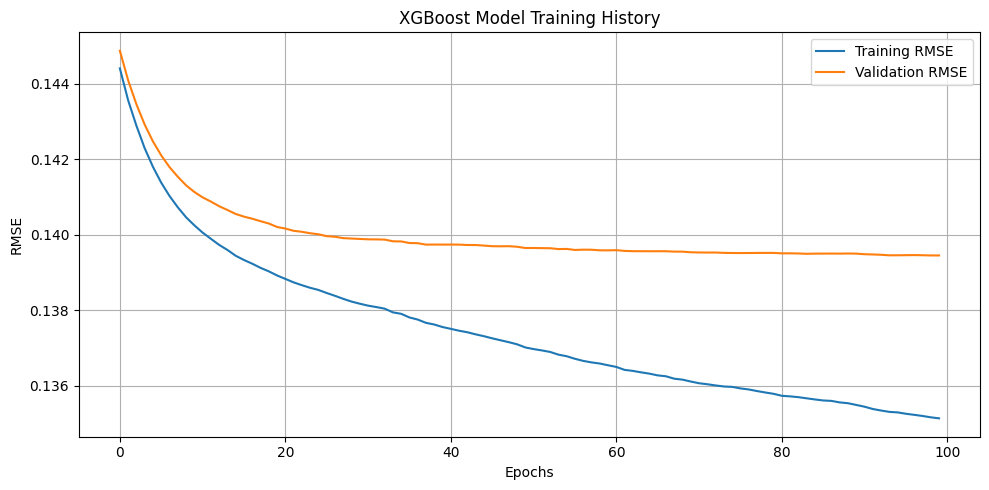

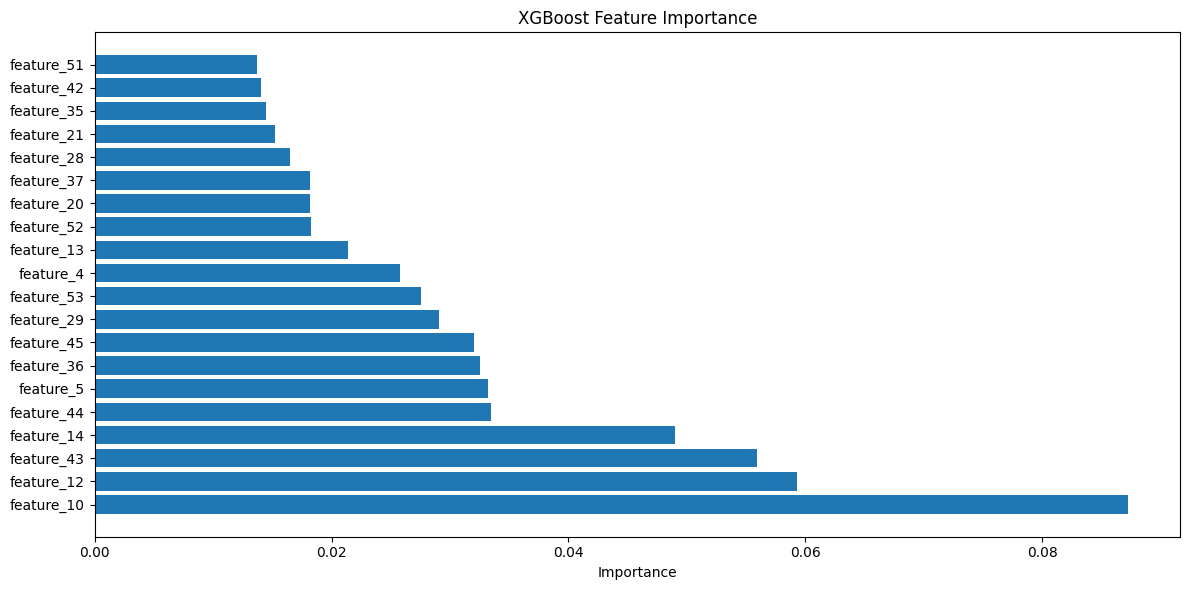

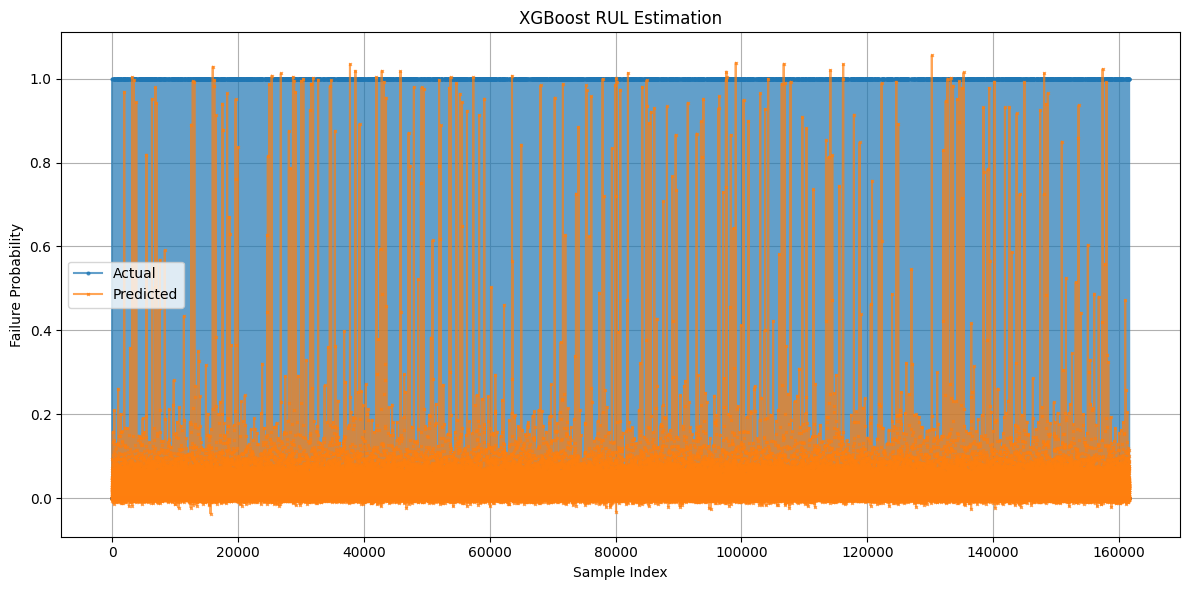

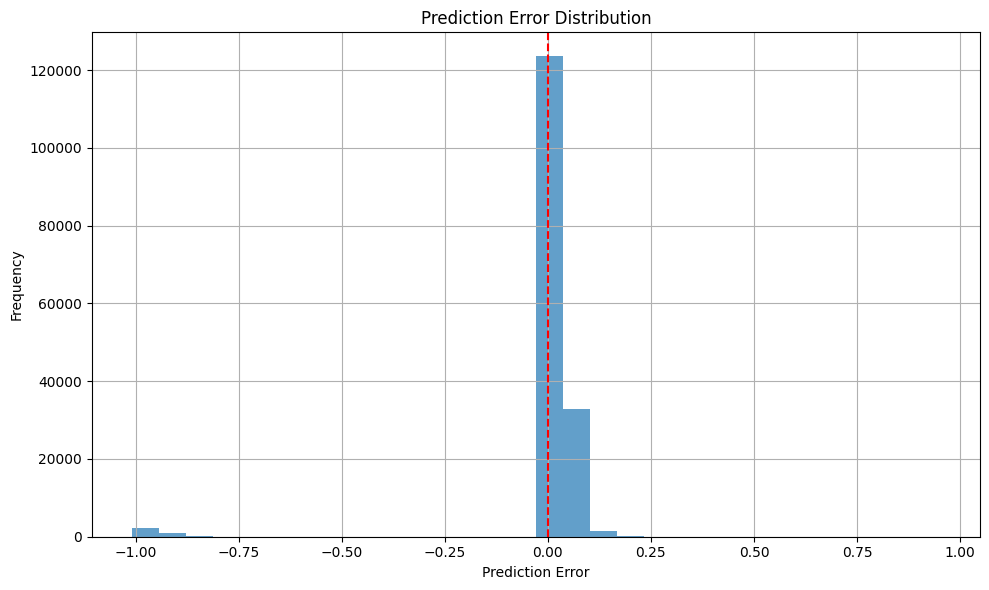

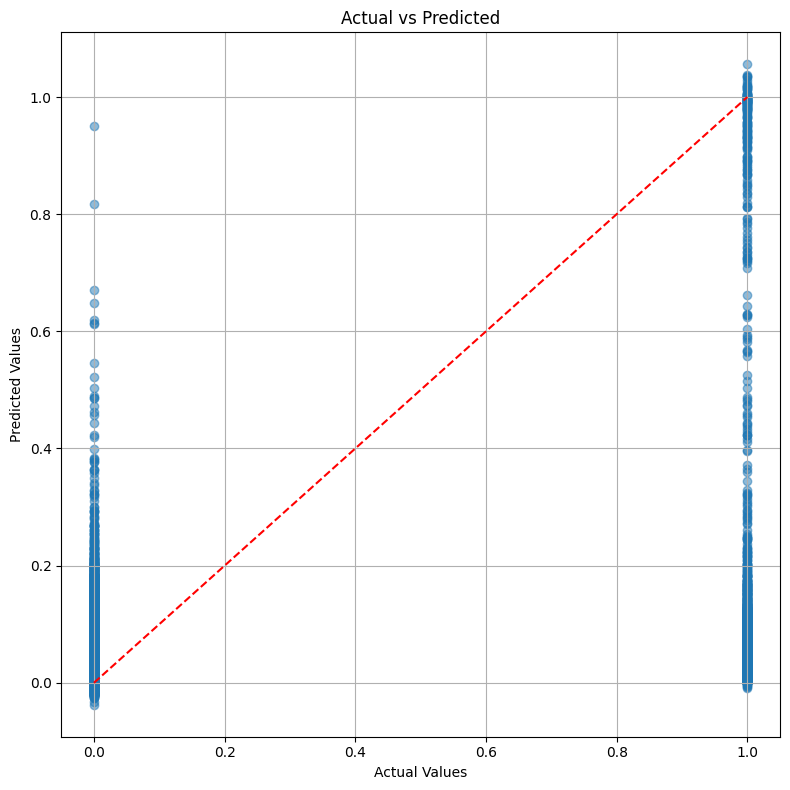

In [ ]:
xgb_model, predictions, actual_values = xgboost_rul_estimation(X_train, X_test, y_train_fault, y_test_fault, features)